# Lab 3: Multi-Source Retail Sales Data Integration and Analysis

**Domain:** Retail Analytics  
**Dataset:** UCI Online Retail Dataset

## Objective

The objective of this experiment is to perform end-to-end retail data
processing using the UCI Online Retail dataset.

The original dataset contains transaction, product and customer-related
information in a single Excel file. To simulate a multi-source retail
environment, the dataset is logically divided into three data sources:

1. Transaction data
2. Product data
3. Customer data

## Installing Required Libraries

In [ ]:
install.packages(
  c("readxl", "dplyr", "DBI", "RSQLite"),
  repos = "https://cloud.r-project.org"
)

In [69]:
library(readxl)
library(dplyr)
library(tidyr)
library(DBI)
library(RSQLite)
library(ggplot2)
library(lubridate)

## 1. Import the UCI Online Retail Dataset

The UCI Online Retail dataset is provided as an Excel file named
`Online Retail.xlsx`.

Unlike the original problem statement, where transaction, product and
customer information are stored separately, the supplied dataset contains
all required information in a single Excel file.

Therefore, the dataset will first be imported into R and then logically
separated into transaction, product and customer tables.

In [7]:
file_path <- "/content/Online Retail.xlsx"

retail_raw <- read_excel(file_path)

head(retail_raw)

InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom


## Dataset Inspection

The dataset is inspected to understand:

- Number of records
- Number of attributes
- Column names
- Data types
- Missing values
- Duplicate records

In [8]:
dim(retail_raw)

[1] 541909      8

In [9]:
names(retail_raw)

[1] "InvoiceNo"   "StockCode"   "Description" "Quantity"    "InvoiceDate"
[6] "UnitPrice"   "CustomerID"  "Country"

In [10]:
str(retail_raw)

tibble [541,909 × 8] (S3: tbl_df/tbl/data.frame)
 $ InvoiceNo  : chr [1:541909] "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr [1:541909] "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr [1:541909] "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : num [1:541909] 6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: POSIXct[1:541909], format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...
 $ UnitPrice  : num [1:541909] 2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : num [1:541909] 17850 17850 17850 17850 17850 ...
 $ Country    : chr [1:541909] "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...


In [11]:
summary(retail_raw)

     InvoiceNo          StockCode         Description        Quantity         
 Length   :541909   Length   :541909   Length   :541909   Min.   :-80995.000  
 N.unique : 25900   N.unique :  4070   N.unique :  4211   1st Qu.:     1.000  
 N.blank  :     0   N.blank  :     0   N.blank  :     0   Median :     3.000  
 Min.nchar:     6   Min.nchar:     1   Min.nchar:     1   Mean   :     9.552  
 Max.nchar:     7   Max.nchar:    12   Max.nchar:    35   3rd Qu.:    10.000  
                                       NAs      :  1454   Max.   : 80995.000  
                                                                              
  InvoiceDate                    UnitPrice            CustomerID    
 Min.   :2010-12-01 08:26:00   Min.   :-11062.060   Min.   :12346   
 1st Qu.:2011-03-28 11:34:00   1st Qu.:     1.250   1st Qu.:13953   
 Median :2011-07-19 17:17:00   Median :     2.080   Median :15152   
 Mean   :2011-07-04 13:34:57   Mean   :     4.611   Mean   :15288   
 3rd Qu.:2011-10-19 11:

In [12]:
cat("Number of rows:", nrow(retail_raw), "\n")
cat("Number of columns:", ncol(retail_raw), "\n")

Number of rows: 541909 
Number of columns: 8 


## Missing Value Analysis

Missing values are checked for every column.

`CustomerID` contains missing values in the original UCI Online Retail
dataset. Since customer-level analysis is required in this experiment,
records without a CustomerID will not be used for the final customer and
revenue analysis.

Missing descriptions are also removed because product-level analysis
requires a valid product description.

In [13]:
missing_values <- colSums(is.na(retail_raw))
missing_values

InvoiceNo   StockCode Description    Quantity InvoiceDate   UnitPrice 
          0           0        1454           0           0           0 
 CustomerID     Country 
     135080           0

In [14]:
missing_percentage <- colMeans(is.na(retail_raw)) * 100
round(missing_percentage, 2)

InvoiceNo   StockCode Description    Quantity InvoiceDate   UnitPrice 
       0.00        0.00        0.27        0.00        0.00        0.00 
 CustomerID     Country 
      24.93        0.00

## Duplicate Record Analysis

Duplicate transaction records can affect revenue calculations. Therefore,
duplicate rows are identified and removed during preprocessing.

In [15]:
duplicate_count <- sum(duplicated(retail_raw))

cat("Number of duplicate records:", duplicate_count, "\n")

Number of duplicate records: 5268 


## Creating the Transaction Data Source

The transaction table contains:

- InvoiceNo
- StockCode
- CustomerID
- Quantity
- InvoiceDate

This represents the transaction-level information in the retail system.

In [16]:
transactions <- retail_raw %>%
  select(
    InvoiceNo,
    StockCode,
    CustomerID,
    Quantity,
    InvoiceDate
  )

head(transactions)

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate
<chr>,<chr>,<dbl>,<dbl>,<dttm>
536365,85123A,17850,6,2010-12-01 08:26:00
536365,71053,17850,6,2010-12-01 08:26:00
536365,84406B,17850,8,2010-12-01 08:26:00
536365,84029G,17850,6,2010-12-01 08:26:00
536365,84029E,17850,6,2010-12-01 08:26:00
536365,22752,17850,2,2010-12-01 08:26:00


## Creating the Product Data Source

The product table contains:

- StockCode
- Description
- UnitPrice

Each StockCode represents a product identifier.

In [17]:
products <- retail_raw %>%
  select(
    StockCode,
    Description,
    UnitPrice
  ) %>%
  distinct(StockCode, .keep_all = TRUE)

head(products)

StockCode,Description,UnitPrice
<chr>,<chr>,<dbl>
85123A,WHITE HANGING HEART T-LIGHT HOLDER,2.55
71053,WHITE METAL LANTERN,3.39
84406B,CREAM CUPID HEARTS COAT HANGER,2.75
84029G,KNITTED UNION FLAG HOT WATER BOTTLE,3.39
84029E,RED WOOLLY HOTTIE WHITE HEART.,3.39
22752,SET 7 BABUSHKA NESTING BOXES,7.65


## Creating the Customer Data Source

The customer table contains:

- CustomerID
- Country

Each CustomerID represents a customer.

In [18]:
customers <- retail_raw %>%
  select(
    CustomerID,
    Country
  ) %>%
  filter(!is.na(CustomerID)) %>%
  distinct(CustomerID, .keep_all = TRUE)

head(customers)

CustomerID,Country
<dbl>,<chr>
17850,United Kingdom
13047,United Kingdom
12583,France
13748,United Kingdom
15100,United Kingdom
15291,United Kingdom


In [19]:
cat("Transactions:", nrow(transactions), "rows\n")
cat("Products:", nrow(products), "rows\n")
cat("Customers:", nrow(customers), "rows\n")

Transactions: 541909 rows
Products: 4070 rows
Customers: 4372 rows


In [20]:
cat("Transaction columns:\n")
names(transactions)

cat("\nProduct columns:\n")
names(products)

cat("\nCustomer columns:\n")
names(customers)

Transaction columns:


[1] "InvoiceNo"   "StockCode"   "CustomerID"  "Quantity"    "InvoiceDate"


Product columns:


[1] "StockCode"   "Description" "UnitPrice"


Customer columns:


[1] "CustomerID" "Country"

## Data Cleaning: Transactions

The following cleaning operations are performed:

1. Remove duplicate records.
2. Remove records with missing CustomerID.
3. Remove records with missing StockCode.
4. Remove transactions with zero or negative quantities.
5. Convert InvoiceDate to a proper date-time format.

Negative quantities occur in the dataset because some records represent
returns or cancellations. For this sales-revenue analysis, only positive
quantities are retained.

In [21]:
transactions_clean <- transactions %>%
  distinct() %>%
  filter(
    !is.na(CustomerID),
    !is.na(StockCode),
    Quantity > 0
  ) %>%
  mutate(
    InvoiceDate = as.POSIXct(InvoiceDate)
  )

In [22]:
dim(transactions_clean)

[1] 392708      5

## Data Cleaning: Products

Product records are cleaned by:

- Removing missing StockCode values
- Removing missing descriptions
- Removing missing UnitPrice values
- Removing zero or negative UnitPrice values
- Keeping one record per StockCode

Only products with valid positive prices are retained for revenue analysis.

In [23]:
products_clean <- products %>%
  mutate(
    UnitPrice = as.numeric(UnitPrice)
  ) %>%
  filter(
    !is.na(StockCode),
    !is.na(Description),
    !is.na(UnitPrice),
    UnitPrice > 0
  ) %>%
  distinct(StockCode, .keep_all = TRUE)

In [24]:
dim(products_clean)

[1] 3855    3

## Data Cleaning: Customers

Customer records without a CustomerID cannot be uniquely identified.
Therefore, records with missing CustomerID are removed.

Duplicate CustomerID records are also removed because the customer table
should contain one logical record per customer.

In [25]:
customers_clean <- customers %>%
  filter(
    !is.na(CustomerID),
    !is.na(Country)
  ) %>%
  distinct(CustomerID, .keep_all = TRUE)

In [26]:
dim(customers_clean)

[1] 4372    2

In [27]:
cat("========== CLEANING SUMMARY ==========\n")

cat("Original records:", nrow(retail_raw), "\n")
cat("Clean transactions:", nrow(transactions_clean), "\n")
cat("Clean products:", nrow(products_clean), "\n")
cat("Clean customers:", nrow(customers_clean), "\n")

========== CLEANING SUMMARY ==========
Original records: 541909 
Clean transactions: 392708 
Clean products: 3855 
Clean customers: 4372 


# Task 2: Integrate the Multiple Data Sources

Although the supplied UCI dataset is stored in one Excel file, three logical
data sources were created from it:

**Transactions + Products + Customers**

The tables are integrated using:

- `left_join()` between transactions and products using `StockCode`
- `left_join()` between the resulting dataset and customers using `CustomerID`

`left_join()` is selected because transactions are the primary dataset and
all valid transactions should initially be preserved while checking for
matching product and customer information.

In [28]:
transaction_product <- transactions_clean %>%
  left_join(
    products_clean,
    by = "StockCode"
  )

In [29]:
dim(transaction_product)

[1] 392708      7

In [30]:
head(transaction_product)

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate,Description,UnitPrice
<chr>,<chr>,<dbl>,<dbl>,<dttm>,<chr>,<dbl>
536365,85123A,17850,6,2010-12-01 08:26:00,WHITE HANGING HEART T-LIGHT HOLDER,2.55
536365,71053,17850,6,2010-12-01 08:26:00,WHITE METAL LANTERN,3.39
536365,84406B,17850,8,2010-12-01 08:26:00,CREAM CUPID HEARTS COAT HANGER,2.75
536365,84029G,17850,6,2010-12-01 08:26:00,KNITTED UNION FLAG HOT WATER BOTTLE,3.39
536365,84029E,17850,6,2010-12-01 08:26:00,RED WOOLLY HOTTIE WHITE HEART.,3.39
536365,22752,17850,2,2010-12-01 08:26:00,SET 7 BABUSHKA NESTING BOXES,7.65


## Checking Unmatched Product Records

After joining transactions with products, records where `Description` or
`UnitPrice` is missing indicate that the transaction could not be matched
with the product table.

In [31]:
unmatched_products <- transaction_product %>%
  filter(
    is.na(Description) |
    is.na(UnitPrice)
  )

cat(
  "Unmatched product records:",
  nrow(unmatched_products),
  "\n"
)

Unmatched product records: 4831 


In [32]:
retail_data <- transaction_product %>%
  left_join(
    customers_clean,
    by = "CustomerID"
  )

In [33]:
dim(retail_data)

[1] 392708      8

In [34]:
unmatched_customers <- retail_data %>%
  filter(is.na(Country))

cat(
  "Unmatched customer records:",
  nrow(unmatched_customers),
  "\n"
)

Unmatched customer records: 0 


## Revenue Calculation

Revenue is calculated for every valid transaction using:

**Revenue = Quantity × UnitPrice**

This creates a new attribute named `Revenue`.

In [35]:
retail_data <- retail_data %>%
  filter(
    !is.na(UnitPrice),
    !is.na(Country)
  ) %>%
  mutate(
    Revenue = Quantity * UnitPrice
  )

In [36]:
head(retail_data)

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate,Description,UnitPrice,Country,Revenue
<chr>,<chr>,<dbl>,<dbl>,<dttm>,<chr>,<dbl>,<chr>,<dbl>
536365,85123A,17850,6,2010-12-01 08:26:00,WHITE HANGING HEART T-LIGHT HOLDER,2.55,United Kingdom,15.30
536365,71053,17850,6,2010-12-01 08:26:00,WHITE METAL LANTERN,3.39,United Kingdom,20.34
536365,84406B,17850,8,2010-12-01 08:26:00,CREAM CUPID HEARTS COAT HANGER,2.75,United Kingdom,22.00
536365,84029G,17850,6,2010-12-01 08:26:00,KNITTED UNION FLAG HOT WATER BOTTLE,3.39,United Kingdom,20.34
536365,84029E,17850,6,2010-12-01 08:26:00,RED WOOLLY HOTTIE WHITE HEART.,3.39,United Kingdom,20.34
536365,22752,17850,2,2010-12-01 08:26:00,SET 7 BABUSHKA NESTING BOXES,7.65,United Kingdom,15.30


In [37]:
cat("Final number of rows:", nrow(retail_data), "\n")
cat("Final number of columns:", ncol(retail_data), "\n")

Final number of rows: 387877 
Final number of columns: 9 


In [38]:
names(retail_data)

[1] "InvoiceNo"   "StockCode"   "CustomerID"  "Quantity"    "InvoiceDate"
[6] "Description" "UnitPrice"   "Country"     "Revenue"

In [39]:
sum(is.na(retail_data))

[1] 0

In [40]:
sum(duplicated(retail_data))

[1] 0

In [41]:
summary(retail_data$Revenue)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
1.000e-03 5.040e+00 1.320e+01 2.772e+01 2.080e+01 1.685e+05 

# Task 3: Sales and Customer Analysis

## 3.1 Total Sales Revenue

The total sales revenue is calculated by summing the Revenue column across
all valid transactions.

In [42]:
total_revenue <- retail_data %>%
  summarise(
    Total_Revenue = sum(Revenue)
  )

total_revenue

Total_Revenue
<dbl>
10752840


## 3.2 Top 5 Products Based on Revenue

Products are grouped using StockCode and Description. Revenue is aggregated
for each product and sorted in descending order.

In [43]:
top_5_products <- retail_data %>%
  group_by(
    StockCode,
    Description
  ) %>%
  summarise(
    Total_Revenue = sum(Revenue),
    Total_Quantity = sum(Quantity),
    .groups = "drop"
  ) %>%
  arrange(desc(Total_Revenue)) %>%
  slice_head(n = 5)

top_5_products

StockCode,Description,Total_Revenue,Total_Quantity
<chr>,<chr>,<dbl>,<dbl>
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995
47566,PARTY BUNTING,142437.56,15283
22423,REGENCY CAKESTAND 3 TIER,135604.80,12384
85123A,WHITE HANGING HEART T-LIGHT HOLDER,93745.65,36763
23166,MEDIUM CERAMIC TOP STORAGE JAR,81032.64,77916


## 3.3 Top 5 Countries Based on Revenue

Revenue is aggregated at country level to identify the strongest markets.

In [44]:
top_5_countries <- retail_data %>%
  group_by(Country) %>%
  summarise(
    Total_Revenue = sum(Revenue),
    .groups = "drop"
  ) %>%
  arrange(desc(Total_Revenue)) %>%
  slice_head(n = 5)

top_5_countries

Country,Total_Revenue
<chr>,<dbl>
United Kingdom,8861857.1
Netherlands,363884.5
EIRE,331660.2
Germany,263819.0
France,226975.6


## 3.4 Top 5 Customers Based on Total Purchase Value

Customer purchase value is calculated by summing the revenue generated by
each customer.

In [45]:
top_5_customers <- retail_data %>%
  group_by(CustomerID) %>%
  summarise(
    Total_Purchase_Value = sum(Revenue),
    .groups = "drop"
  ) %>%
  arrange(desc(Total_Purchase_Value)) %>%
  slice_head(n = 5)

top_5_customers

CustomerID,Total_Purchase_Value
<dbl>,<dbl>
18102,408760.0
14646,357531.1
17450,186038.0
14911,182690.5
16446,168472.5


## 3.5 Customer Value Classification

Customers are classified into four categories:

- Low Value
- Medium Value
- High Value
- Premium

Instead of selecting arbitrary monetary thresholds, quartiles are used.

The thresholds are calculated from the distribution of total customer
purchase values:

- Q1 → boundary between Low and Medium
- Median → boundary between Medium and High
- Q3 → boundary between High and Premium

The classification is implemented using `case_when()`.

In [46]:
customer_value <- retail_data %>%
  group_by(CustomerID) %>%
  summarise(
    Total_Purchase_Value = sum(Revenue),
    .groups = "drop"
  )

In [47]:
q1 <- quantile(
  customer_value$Total_Purchase_Value,
  0.25,
  na.rm = TRUE
)

median_value <- quantile(
  customer_value$Total_Purchase_Value,
  0.50,
  na.rm = TRUE
)

q3 <- quantile(
  customer_value$Total_Purchase_Value,
  0.75,
  na.rm = TRUE
)

cat("Q1:", q1, "\n")
cat("Median:", median_value, "\n")
cat("Q3:", q3, "\n")

Q1: 361.005 
Median: 802.6 
Q3: 2000.64 


In [48]:
customer_value <- customer_value %>%
  mutate(
    Customer_Segment = case_when(
      Total_Purchase_Value <= q1 ~ "Low Value",
      Total_Purchase_Value <= median_value ~ "Medium Value",
      Total_Purchase_Value <= q3 ~ "High Value",
      TRUE ~ "Premium"
    )
  )

In [49]:
head(customer_value)

CustomerID,Total_Purchase_Value,Customer_Segment
<dbl>,<dbl>,<chr>
12346,77183.60,Premium
12347,5438.44,Premium
12348,1790.16,High Value
12349,1926.96,High Value
12350,408.04,Medium Value
12352,1616.57,High Value


In [50]:
customer_segments <- customer_value %>%
  group_by(Customer_Segment) %>%
  summarise(
    Number_of_Customers = n(),
    Total_Revenue = sum(Total_Purchase_Value),
    Average_Purchase_Value = mean(Total_Purchase_Value),
    .groups = "drop"
  ) %>%
  arrange(desc(Total_Revenue))

customer_segments

Customer_Segment,Number_of_Customers,Total_Revenue,Average_Purchase_Value
<chr>,<int>,<dbl>,<dbl>
Premium,1085,8518195.8,7850.8717
High Value,1084,1400834.6,1292.2829
Medium Value,1085,604126.7,556.7988
Low Value,1085,229682.9,211.6893


## 3.6 Market Performance Analysis

Countries are evaluated based on total revenue.

The country with the highest revenue is considered the high-performing
market.

The country with the lowest revenue is considered the underperforming
market.

Revenue is used as the primary performance metric because the dataset does
not contain cost or profit information.

In [51]:
market_performance <- retail_data %>%
  group_by(Country) %>%
  summarise(
    Total_Revenue = sum(Revenue),
    Number_of_Customers = n_distinct(CustomerID),
    Number_of_Transactions = n(),
    .groups = "drop"
  ) %>%
  arrange(desc(Total_Revenue))

market_performance

Country,Total_Revenue,Number_of_Customers,Number_of_Transactions
<chr>,<dbl>,<int>,<int>
United Kingdom,8861857.13,3921,344847
Netherlands,363884.48,9,2340
EIRE,331660.17,3,7155
Germany,263818.97,94,8934
France,226975.60,87,8196
Australia,173918.61,9,1242
Spain,67426.09,28,2396
Switzerland,66619.97,20,1815
Japan,48600.22,8,321


In [52]:
high_performing_market <- market_performance %>%
  slice_max(
    order_by = Total_Revenue,
    n = 1
  )

underperforming_market <- market_performance %>%
  slice_min(
    order_by = Total_Revenue,
    n = 1
  )

high_performing_market
underperforming_market

Country,Total_Revenue,Number_of_Customers,Number_of_Transactions
<chr>,<dbl>,<int>,<int>
United Kingdom,8861857,3921,344847


Country,Total_Revenue,Number_of_Customers,Number_of_Transactions
<chr>,<dbl>,<int>,<int>
Saudi Arabia,181.44,1,9


In [53]:
cat(
  "High-performing market:",
  high_performing_market$Country,
  "\n"
)

cat(
  "Revenue:",
  round(high_performing_market$Total_Revenue, 2),
  "\n\n"
)

cat(
  "Underperforming market:",
  underperforming_market$Country,
  "\n"
)

cat(
  "Revenue:",
  round(underperforming_market$Total_Revenue, 2),
  "\n"
)

High-performing market: United Kingdom 
Revenue: 8861857 

Underperforming market: Saudi Arabia 
Revenue: 181.44 


### Market Interpretation

The high-performing market is the country with the highest total revenue.
Its strong revenue contribution indicates a relatively strong sales presence
in the dataset.

The underperforming market has the lowest total revenue. This could be due
to fewer customers, fewer transactions, lower purchase frequency or lower
average transaction value.

Therefore, revenue should be considered together with customer count and
transaction count when making strategic decisions.

# Task 4: Store and Retrieve Data Using SQL

The final cleaned and integrated dataset is stored in a SQLite database.

**Database:** `retail_sales.db`

**Table:** `retail_sales`

In [54]:
db_path <- "/content/retail_sales.db"

con <- dbConnect(
  SQLite(),
  db_path
)

In [55]:
dbWriteTable(
  con,
  "retail_sales",
  retail_data,
  overwrite = TRUE
)

In [56]:
dbListTables(con)

[1] "retail_sales"

In [57]:
dbGetQuery(
  con,
  "SELECT COUNT(*) AS Total_Records
   FROM retail_sales"
)

Total_Records
<int>
387877


In [58]:
dbGetQuery(
  con,
  "SELECT *
   FROM retail_sales
   LIMIT 10"
)

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate,Description,UnitPrice,Country,Revenue
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>
536365,85123A,17850,6,1291191960,WHITE HANGING HEART T-LIGHT HOLDER,2.55,United Kingdom,15.30
536365,71053,17850,6,1291191960,WHITE METAL LANTERN,3.39,United Kingdom,20.34
536365,84406B,17850,8,1291191960,CREAM CUPID HEARTS COAT HANGER,2.75,United Kingdom,22.00
536365,84029G,17850,6,1291191960,KNITTED UNION FLAG HOT WATER BOTTLE,3.39,United Kingdom,20.34
536365,84029E,17850,6,1291191960,RED WOOLLY HOTTIE WHITE HEART.,3.39,United Kingdom,20.34
536365,22752,17850,2,1291191960,SET 7 BABUSHKA NESTING BOXES,7.65,United Kingdom,15.30
536365,21730,17850,6,1291191960,GLASS STAR FROSTED T-LIGHT HOLDER,4.25,United Kingdom,25.50
536366,22633,17850,6,1291192080,HAND WARMER UNION JACK,1.85,United Kingdom,11.10
536366,22632,17850,6,1291192080,HAND WARMER RED POLKA DOT,1.85,United Kingdom,11.10


## SQL Query 1: Top 5 Customers by Revenue

The following SQL query calculates the total purchase value of each customer
and returns the five customers with the highest revenue.

In [59]:
query_1 <- "
SELECT
    CustomerID,
    SUM(Revenue) AS Total_Revenue
FROM retail_sales
GROUP BY CustomerID
ORDER BY Total_Revenue DESC
LIMIT 5;
"

top_customers_sql <- dbGetQuery(
  con,
  query_1
)

top_customers_sql

CustomerID,Total_Revenue
<dbl>,<dbl>
18102,408760.0
14646,357531.1
17450,186038.0
14911,182690.5
16446,168472.5


## SQL Query 2: Total Revenue by Country

The following query calculates total sales revenue for each country and
orders the markets from highest to lowest revenue.

In [60]:
query_2 <- "
SELECT
    Country,
    SUM(Revenue) AS Total_Revenue
FROM retail_sales
GROUP BY Country
ORDER BY Total_Revenue DESC;
"

revenue_country_sql <- dbGetQuery(
  con,
  query_2
)

head(revenue_country_sql, 10)

,Country,Total_Revenue
,<chr>,<dbl>
1,United Kingdom,8861857.13
2,Netherlands,363884.48
3,EIRE,331660.17
4,Germany,263818.97
5,France,226975.60
6,Australia,173918.61
7,Spain,67426.09
8,Switzerland,66619.97
9,Japan,48600.22


## Additional SQL Query: Overall Retail Performance

This query retrieves the total revenue, number of transactions and number of
unique customers from the SQLite database.

In [61]:
query_3 <- "
SELECT
    SUM(Revenue) AS Total_Revenue,
    COUNT(*) AS Total_Transactions,
    COUNT(DISTINCT CustomerID) AS Total_Customers
FROM retail_sales;
"

dbGetQuery(
  con,
  query_3
)

Total_Revenue,Total_Transactions,Total_Customers
<dbl>,<int>,<int>
10752840,387877,4339


## SQLite Table Structure

The database schema is inspected using SQLite's `PRAGMA` command.

In [62]:
dbGetQuery(
  con,
  "PRAGMA table_info(retail_sales)"
)

cid,name,type,notnull,dflt_value,pk
<int>,<chr>,<chr>,<int>,<lgl>,<int>
0,InvoiceNo,TEXT,0,NA,0
1,StockCode,TEXT,0,NA,0
2,CustomerID,REAL,0,NA,0
3,Quantity,REAL,0,NA,0
4,InvoiceDate,REAL,0,NA,0
5,Description,TEXT,0,NA,0
6,UnitPrice,REAL,0,NA,0
7,Country,TEXT,0,NA,0
8,Revenue,REAL,0,NA,0


In [63]:
dbDisconnect(con)

In [64]:
file.exists("/content/retail_sales.db")

[1] TRUE

# Data Visualization

Visualizations are created to better understand product, market and customer
performance.

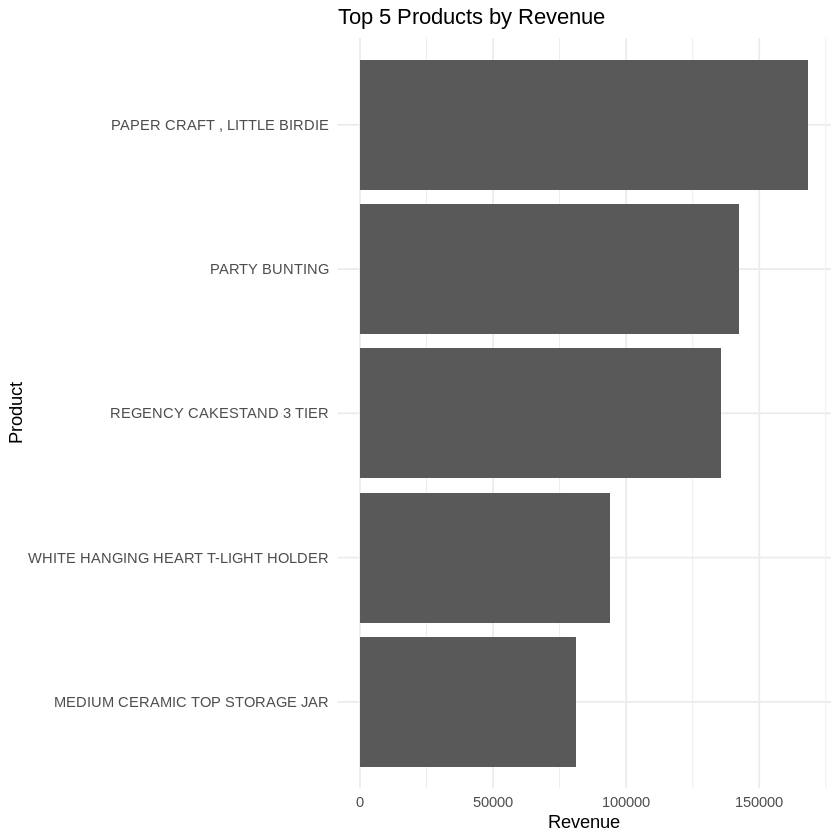

In [65]:
ggplot(
  top_5_products,
  aes(
    x = reorder(Description, Total_Revenue),
    y = Total_Revenue
  )
) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top 5 Products by Revenue",
    x = "Product",
    y = "Revenue"
  ) +
  theme_minimal()

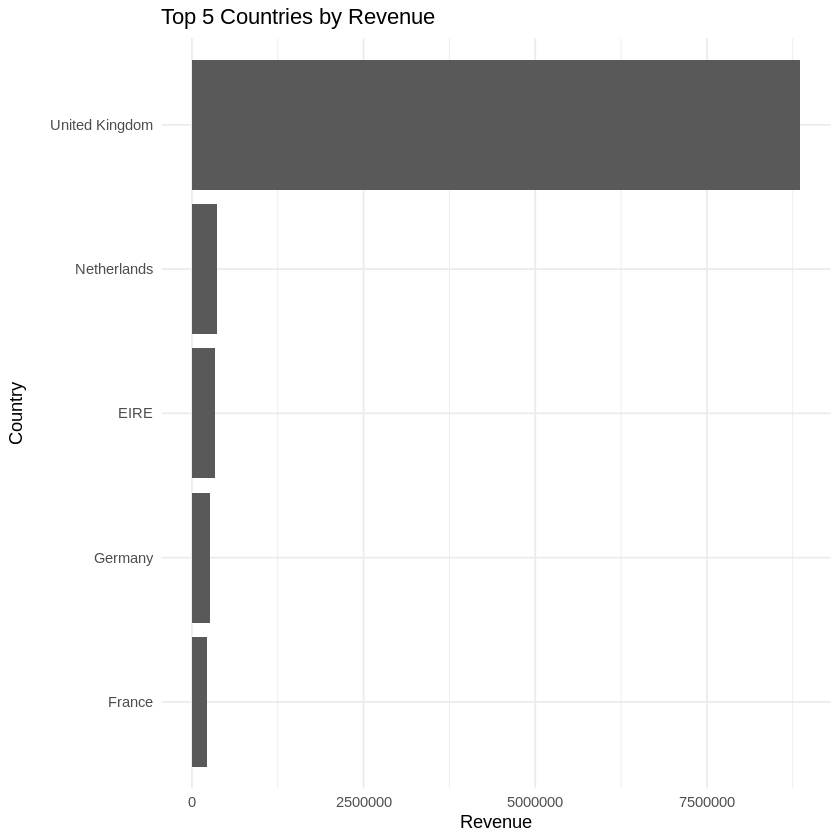

In [66]:
ggplot(
  top_5_countries,
  aes(
    x = reorder(Country, Total_Revenue),
    y = Total_Revenue
  )
) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top 5 Countries by Revenue",
    x = "Country",
    y = "Revenue"
  ) +
  theme_minimal()

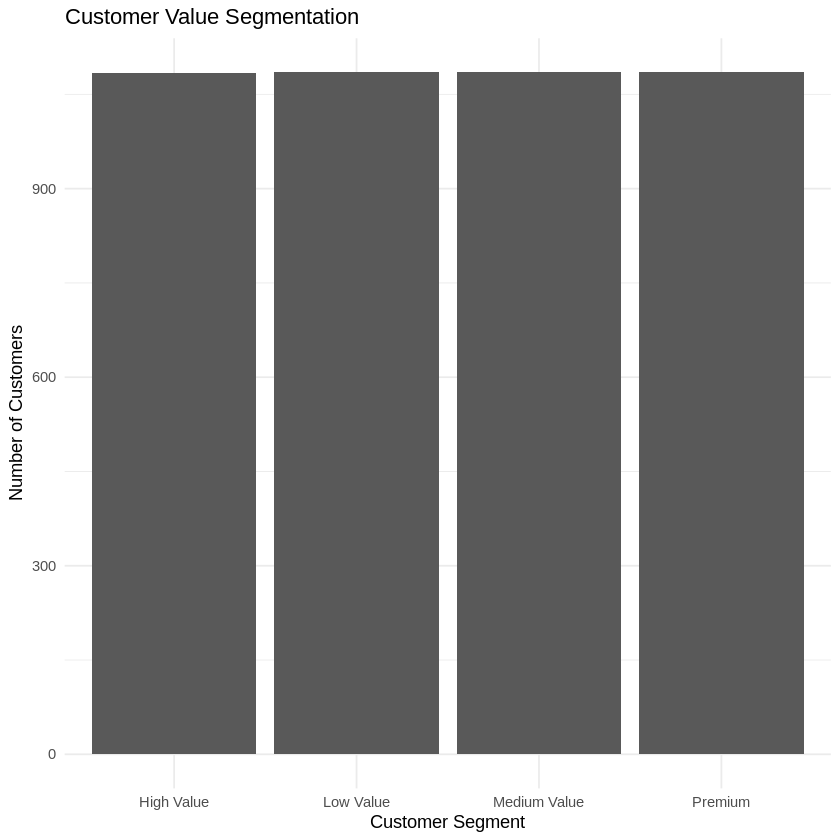

In [67]:
ggplot(
  customer_segments,
  aes(
    x = Customer_Segment,
    y = Number_of_Customers
  )
) +
  geom_col() +
  labs(
    title = "Customer Value Segmentation",
    x = "Customer Segment",
    y = "Number of Customers"
  ) +
  theme_minimal()

# Final Validation

The following checks verify that the final dataset is ready for analysis
and database storage.

In [68]:
cat("========== FINAL VALIDATION ==========\n")

cat(
  "Final Rows:",
  nrow(retail_data),
  "\n"
)

cat(
  "Final Columns:",
  ncol(retail_data),
  "\n"
)

cat(
  "Missing Values:",
  sum(is.na(retail_data)),
  "\n"
)

cat(
  "Duplicate Rows:",
  sum(duplicated(retail_data)),
  "\n"
)

cat(
  "Total Revenue:",
  round(sum(retail_data$Revenue), 2),
  "\n"
)

cat(
  "Unique Customers:",
  n_distinct(retail_data$CustomerID),
  "\n"
)

cat(
  "Unique Products:",
  n_distinct(retail_data$StockCode),
  "\n"
)

cat(
  "Unique Countries:",
  n_distinct(retail_data$Country),
  "\n"
)

========== FINAL VALIDATION ==========
Final Rows: 387877 
Final Columns: 9 
Missing Values: 0 
Duplicate Rows: 0 
Total Revenue: 10752840 
Unique Customers: 4339 
Unique Products: 3587 
Unique Countries: 37 


# Business Insights

## Insight 1: Product Performance

The Top 5 product analysis identifies the products contributing the greatest
share of revenue. These products should receive priority in inventory
planning, availability management and promotional strategies.

## Insight 2: Market Performance

Revenue varies across countries. The highest-revenue country represents the
strongest market in the dataset, while the lowest-revenue country may require
additional customer acquisition, marketing or market-development efforts.

## Insight 3: Customer Value

Customer segmentation divides customers into Low Value, Medium Value, High
Value and Premium groups. Premium and High Value customers represent
important retention opportunities because they contribute higher purchase
values. Low Value customers can be targeted through personalized promotions,
cross-selling and upselling strategies.

# Conclusion

In this experiment, the UCI Online Retail dataset was imported into R and
processed to perform an end-to-end retail analytics workflow.

Although the supplied dataset was provided as a single Excel file, it was
logically separated into three data sources representing transactions,
products and customers. Each logical dataset was independently cleaned and
then integrated using `left_join()` operations.

Data preprocessing included handling missing values, removing duplicate
records, eliminating invalid quantities and prices, and retaining valid
customer and product information.

A new `Revenue` attribute was created using: **Revenue = Quantity × UnitPrice**

The integrated dataset was then analyzed to determine total revenue, top
products, top countries, top customers and customer value segments using
`group_by()`, `summarise()`, `arrange()`, `slice_head()` and `case_when()`.

Finally, the processed dataset was stored in a SQLite database named
`retail_sales.db`, and SQL queries were executed from R to retrieve
customer and country-level sales information.

The experiment demonstrates practical skills in data import, cleaning,
multi-table integration, business analytics, customer segmentation and
SQL-based data management using R.